# Evaluation Metrics: Confusion Matrix, Precision, Recall, and F1-Score


## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain why accuracy alone can give a false sense of how good a classifier is.
2. Construct a confusion matrix for a binary classifier and correctly identify True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).
3. Compute Accuracy, Precision, Recall, and F1-score from a confusion matrix, by hand and using scikit-learn.
4. Explain, in plain language, what precision and recall each actually measure, and the trade-off between them.
5. Evaluate a classifier on an imbalanced dataset and explain *why* precision, recall, and F1-score matter more than accuracy in that setting.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, precision_recall_curve
)

np.random.seed(42)
print("Setup complete.")

Setup complete.


## A Quick Teaser — Keep This Number in Mind

Imagine a hospital is screening 1,000 patients for a rare disease. Only **50 of them (5%)** actually have it; the other 950 do not.

Suppose someone builds a "model" that is extremely lazy: it just predicts **"Healthy"** for every single patient, no matter what.


In [ ]:
n_patients = 1000
n_sick = 50
n_healthy = n_patients - n_sick

y_true_teaser = np.array([0]*n_healthy + [1]*n_sick)   # 0 = healthy, 1 = sick
y_pred_lazy   = np.zeros(n_patients, dtype=int)         # always predicts "healthy" (0)

lazy_accuracy = accuracy_score(y_true_teaser, y_pred_lazy)
print(f"Accuracy of the 'always predict Healthy' model: {lazy_accuracy:.2%}")

Accuracy of the 'always predict Healthy' model: 95.00%


## The Confusion Matrix

A **confusion matrix** is a table that compares a model's predictions against the actual (true) labels, broken down into four categories. For a binary classifier (Positive = the class we care about detecting, e.g., "Sick"), the four categories are:

| | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

Using our disease example (Positive = "Sick"):

- **True Positive (TP):** Model said "Sick", patient really is sick. Correct catch.
- **True Negative (TN):** Model said "Healthy", patient really is healthy. Correctly cleared.
- **False Positive (FP):** Model said "Sick", but patient is actually healthy. A false alarm (a.k.a. "Type I error").
- **False Negative (FN):** Model said "Healthy", but patient is actually sick. A missed case (a.k.a. "Type II error") — often the most dangerous kind of mistake in medical contexts!

The confusion matrix doesn't give you one number — it gives you the **full breakdown** of *how* a model is right or wrong, which is exactly what accuracy hides from you.


## Building a Confusion Matrix

Let's work with a small, easy-to-check example first: 10 email predictions, where **1 = Spam** and **0 = Not Spam**.


In [ ]:
y_true = np.array([1, 0, 1, 1, 0, 0, 1, 0, 0, 1])
y_pred = np.array([1, 0, 0, 1, 0, 1, 1, 0, 0, 0])

for i in range(len(y_true)):
    print(f"Email {i+1}: actual={y_true[i]}  predicted={y_pred[i]}")

Email 1: actual=1  predicted=1
Email 2: actual=0  predicted=0
Email 3: actual=1  predicted=0
Email 4: actual=1  predicted=1
Email 5: actual=0  predicted=0
Email 6: actual=0  predicted=1
Email 7: actual=1  predicted=1
Email 8: actual=0  predicted=0
Email 9: actual=0  predicted=0
Email 10: actual=1  predicted=0


### Practice Cell 1

Before running the code below: go through the 10 emails above **by hand** and count how many TP, TN, FP, and FN there are. Write your counts in the markdown cell below, then run the code cell after it to check yourself.

*(Your answer here: TP = ___, TN = ___, FP = ___, FN = ___)*


In [ ]:
def manual_confusion_counts(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN

TP, TN, FP, FN = manual_confusion_counts(y_true, y_pred)
print(f"TP = {TP}, TN = {TN}, FP = {FP}, FN = {FN}")

TP = 3, TN = 4, FP = 1, FN = 2


Confusion matrix (rows = actual, columns = predicted):
[[4 1]
 [2 3]]


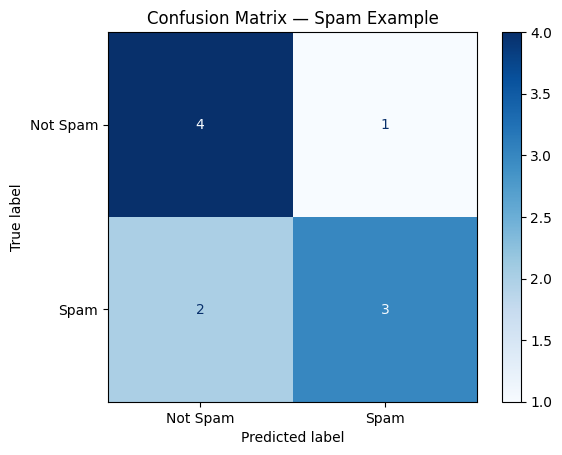

In [ ]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix (rows = actual, columns = predicted):")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Spam", "Spam"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Spam Example")
plt.show()

Note how `confusion_matrix` lays things out: by default, row 0/column 0 is the negative class and row 1/column 1 is the positive class, so:

- `cm[1,1]` = TP, `cm[0,0]` = TN, `cm[0,1]` = FP, `cm[1,0]` = FN

Make sure the numbers printed above match what you counted by hand.


## Accuracy, Precision, Recall, and F1

Once you have TP, TN, FP, and FN, every metric we care about is just a different way of combining them:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall} = \frac{TP}{TP + FN}$$

$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$


- **Accuracy**: "Out of everything, how much did I get right?" Treats both classes equally, which is exactly the problem when one class is rare.
- **Precision**: "Of everything I flagged as Positive, how much did I get right?" High precision = few false alarms. Matters a lot for a spam filter (you don't want important emails marked as spam).
- **Recall** (a.k.a. Sensitivity): "Of everything that was actually Positive, how much did I catch?" High recall = few missed cases. Matters a lot for disease screening (you really don't want to miss a sick patient).
- **F1-score**: the harmonic mean of precision and recall. It's high only when **both** precision and recall are reasonably high, which makes it a good single-number summary when you care about both.


In [ ]:
def manual_metrics(TP, TN, FP, FN):
    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return accuracy, precision, recall, f1

acc, prec, rec, f1 = manual_metrics(TP, TN, FP, FN)
print(f"Manual  -> Accuracy: {acc:.2f}  Precision: {prec:.2f}  Recall: {rec:.2f}  F1: {f1:.2f}")

print(f"sklearn -> Accuracy: {accuracy_score(y_true, y_pred):.2f}  "
      f"Precision: {precision_score(y_true, y_pred):.2f}  "
      f"Recall: {recall_score(y_true, y_pred):.2f}  "
      f"F1: {f1_score(y_true, y_pred):.2f}")

Manual  -> Accuracy: 0.70  Precision: 0.75  Recall: 0.60  F1: 0.67
sklearn -> Accuracy: 0.70  Precision: 0.75  Recall: 0.60  F1: 0.67


In [ ]:
print(classification_report(y_true, y_pred, target_names=["Not Spam", "Spam"]))

              precision    recall  f1-score   support

    Not Spam       0.67      0.80      0.73         5
        Spam       0.75      0.60      0.67         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



`classification_report` is a shortcut that gives you precision, recall, and F1 for **every class**, plus accuracy, all in one readable table, this is the function you'll use most often in practice.

### Practice Cell 2

A different classifier is evaluated on 20 patients and produces this confusion matrix:

```
                 Predicted Healthy   Predicted Sick
Actual Healthy          16                 2
Actual Sick              1                 1
```

By hand, identify TP, TN, FP, FN from this table (remember: "Sick" is the positive class here), then compute Accuracy, Precision, Recall, and F1. Fill in the code cell below to verify your answer.


In [ ]:
# TODO: fill in TP, TN, FP, FN from the table above, then compute the four metrics

TP2 = None
TN2 = None
FP2 = None
FN2 = None

# acc2, prec2, rec2, f1_2 = manual_metrics(TP2, TN2, FP2, FN2)
# print(acc2, prec2, rec2, f1_2)

## The Precision–Recall Trade-off

**Precision and recall usually pull in opposite directions.** A classifier that labels almost everything as "Positive" will catch nearly every real positive case (high recall) but will also raise a lot of false alarms (low precision). A classifier that only labels something "Positive" when it's very confident will have few false alarms (high precision) but will also miss more real cases (low recall).

We can see this directly with Logistic Regression, because it doesn't just predict a class, it predicts a **probability**, and we choose a threshold (normally 0.5) to turn that probability into a class label. Let's use the Breast Cancer dataset and see what happens as we slide that threshold.


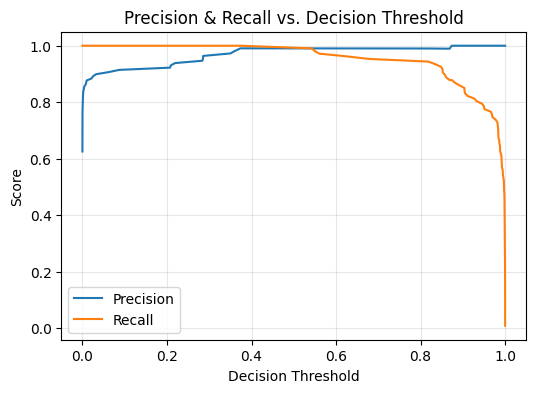

In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target   # NOTE: in this dataset, 1 = benign, 0 = malignant

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = LogisticRegression(max_iter=5000)
clf.fit(X_train, y_train)

y_scores = clf.predict_proba(X_test)[:, 1]   # probability of class 1

precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(6, 4))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs. Decision Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Notice how, as the threshold increases (the model demands more confidence before predicting class 1), precision tends to go up while recall tends to go down and vice versa. There is no free lunch here: **you have to decide which type of mistake (false positive or false negative) is more costly for your specific application**, and pick your threshold/metric accordingly.


Remember the "always predict Healthy" model from Section 1, with its 95% accuracy? Let's run the full confusion matrix and metrics toolkit on it now.


Confusion matrix for the 'always predict Healthy' model:
[[950   0]
 [ 50   0]]


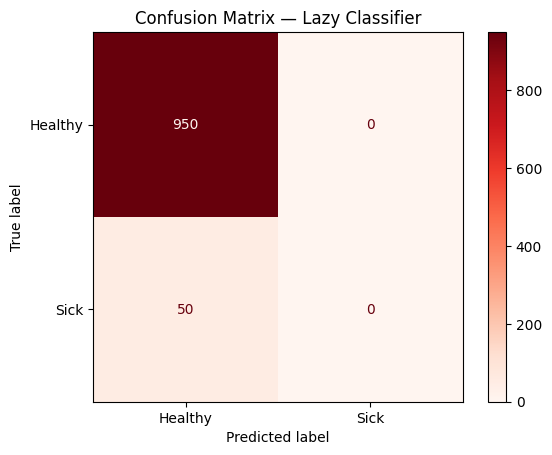


              precision    recall  f1-score   support

     Healthy       0.95      1.00      0.97       950
        Sick       0.00      0.00      0.00        50

    accuracy                           0.95      1000
   macro avg       0.47      0.50      0.49      1000
weighted avg       0.90      0.95      0.93      1000



In [ ]:
cm_lazy = confusion_matrix(y_true_teaser, y_pred_lazy)
print("Confusion matrix for the 'always predict Healthy' model:")
print(cm_lazy)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lazy, display_labels=["Healthy", "Sick"])
disp.plot(cmap="Reds")
plt.title("Confusion Matrix — Lazy Classifier")
plt.show()

print()
print(classification_report(y_true_teaser, y_pred_lazy, target_names=["Healthy", "Sick"], zero_division=0))

Look closely at the row for the **"Sick"** class: Precision, Recall, and F1-score are all **0.00**. The model caught **zero** of the 50 sick patients (FN = 50, TP = 0), it is medically useless, yet accuracy alone told us it was 95% "correct." This is exactly why accuracy can be a misleading metric on imbalanced datasets: it is dominated by whichever class has the most examples, and says nothing about how the model handles the minority (often more important) class.

Now let's see what an actual trained model can do on the same kind of imbalanced data.


In [ ]:
# Build an imbalanced synthetic dataset: 95% class 0, 5% class 1
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=10, n_informative=5,
    weights=[0.95, 0.05], flip_y=0.01, random_state=42
)

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

print("Class balance in training set:", np.bincount(y_train_i))

# A real model, trained on the data (not just guessing the majority class)
real_clf = LogisticRegression(max_iter=5000, class_weight="balanced")
real_clf.fit(X_train_i, y_train_i)
y_pred_real = real_clf.predict(X_test_i)

# A dummy baseline that always predicts the majority class, for comparison
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_i, y_train_i)
y_pred_dummy = dummy.predict(X_test_i)

print("\n--- Dummy classifier (always predicts majority class) ---")
print(f"Accuracy: {accuracy_score(y_test_i, y_pred_dummy):.2%}")
print(classification_report(y_test_i, y_pred_dummy, zero_division=0))

print("--- Real logistic regression classifier ---")
print(f"Accuracy: {accuracy_score(y_test_i, y_pred_real):.2%}")
print(classification_report(y_test_i, y_pred_real, zero_division=0))

Class balance in training set: [662  38]

--- Dummy classifier (always predicts majority class) ---
Accuracy: 94.67%
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       284
           1       0.00      0.00      0.00        16

    accuracy                           0.95       300
   macro avg       0.47      0.50      0.49       300
weighted avg       0.90      0.95      0.92       300

--- Real logistic regression classifier ---
Accuracy: 74.33%
              precision    recall  f1-score   support

           0       0.99      0.74      0.84       284
           1       0.16      0.88      0.27        16

    accuracy                           0.74       300
   macro avg       0.57      0.81      0.56       300
weighted avg       0.95      0.74      0.81       300



Compare the two **Accuracy** numbers first, the dummy classifier's accuracy may well be *higher* than the real model's. If you only looked at accuracy, you might wrongly conclude the dummy classifier is better!

Now compare precision, recall, and F1-score **for class 1** (the minority class) between the two. The real model actually detects some of the minority class examples, while the dummy classifier detects **none** which is the entire point of building a model in the first place. This is exactly why, on imbalanced datasets, you should always look at the confusion matrix and per-class precision/recall/F1 rather than trusting accuracy alone.

### Practice Cell 3

1. In the cell above, change `class_weight="balanced"` to `class_weight=None` for `real_clf` and re-run. What happens to recall for class 1? Why do you think that happens?
2. Change the imbalance ratio in `make_classification` from `weights=[0.95, 0.05]` to `weights=[0.99, 0.01]` (an even rarer minority class) and re-run the whole comparison. What happens to the dummy classifier's accuracy now?

In [ ]:
# TODO: Practice Cell 3 — experiment as described above




## Summary: What We Covered Today

| Concept | Key Idea |
|---|---|
| Confusion Matrix | A 2x2 breakdown of predictions vs. actual labels: TP, TN, FP, FN |
| Accuracy | ((TP+TN) / Total )  can look great even when a model is useless on a rare class |
| Precision | (TP / (TP+FP)) of what I flagged positive, how much was right? |
| Recall | (TP / (TP+FN))  of all the real positives, how many did I catch?" |
| F1-score | Harmonic mean of precision and recall, a balanced single-number summary |
| Imbalanced data | Always inspect the confusion matrix / per-class metrics, accuracy alone can hide a model that never predicts the minority class |
| Precision-Recall trade-off | Raising the decision threshold trades recall for precision, and vice versa |

**Rule of thumb going forward:** whenever you evaluate a classifier in this course (or anywhere else), start with `classification_report()` and look at the confusion matrix don't stop at accuracy.
